# Оптимизация SQL-запросов: теория и практика

Этот ноутбук — практический курс по оптимизации SQL-запросов. Мы разберём, как СУБД
выполняет запрос, как читать план выполнения (`EXPLAIN QUERY PLAN`), и на конкретных
примерах с измерением времени посмотрим, как индексы, форма условий, JOIN'ы, подзапросы
и пагинация влияют на производительность.

**Движок:** для примеров используется SQLite — он встроен в Python, не требует установки
сервера и отлично подходит для обучения. Все обсуждаемые концепции (индексы, планы
выполнения, sargable-выражения, JOIN-оптимизация) универсальны и напрямую переносятся на
PostgreSQL и MySQL — синтаксис `EXPLAIN` и детали планировщика немного отличаются, об этом
будет отдельная сводная таблица в конце.

## План курса

1. Как СУБД выполняет запрос: от SQL до плана выполнения
2. Подготовка тестовой базы данных
3. `EXPLAIN QUERY PLAN`: как читать план
4. Full scan vs индекс
5. Sargable-выражения: почему функция над столбцом "убивает" индекс
6. Составные индексы и правило leftmost prefix
7. Покрывающие индексы (covering index)
8. Оптимизация JOIN
9. Проблема N+1
10. Подзапросы: `IN` vs `EXISTS` vs `JOIN` vs `CTE`
11. `LIKE` и индексы
12. Пагинация: `OFFSET/LIMIT` vs keyset-пагинация
13. Агрегация и `GROUP BY`
14. `ANALYZE` и статистика планировщика
15. Итоговая сводка измерений
16. Памятка + перенос на PostgreSQL / MySQL
17. Задания для самостоятельной работы

## 1. Как СУБД выполняет запрос

Когда вы отправляете `SELECT ... WHERE ...`, СУБД не выполняет его "как написано".
Происходит несколько шагов:

1. **Парсинг** — SQL превращается в дерево разбора, проверяется синтаксис.
2. **Логическая оптимизация** — переписывание запроса в эквивалентную, но более
   удобную форму (например, вынос подзапросов, упрощение условий).
3. **Физическое планирование** — оптимизатор перебирает *варианты выполнения*
   (какой индекс использовать, в каком порядке соединять таблицы, как сортировать)
   и выбирает план с наименьшей оценочной стоимостью (**cost-based optimizer**).
   Стоимость оценивается на основе статистики: количество строк, кардинальность
   (selectivity) значений в столбцах.
4. **Исполнение** — план выполняется, физически читаются страницы с диска/из кеша.

Важно понимать: **вы не пишете "как искать данные", вы описываете "что хотите
получить"**. Как именно СУБД это сделает — full scan, поиск по индексу, hash join,
nested loop join — решает оптимизатор. Задача разработчика — дать оптимизатору
возможность выбрать быстрый план: правильные индексы, статистика, "sargable" условия.

Основной ресурс, за который идёт борьба при оптимизации — это **I/O** (чтение
страниц с диска или из page cache) и **CPU** (сравнения, сортировки, хеширование).
Индекс сокращает I/O: вместо чтения всей таблицы читаются только нужные страницы.

In [1]:
import sqlite3
import time
import random
import os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)
random.seed(42)

DB_PATH = "ecommerce.db"

# копилка результатов измерений для итоговой сводки в конце ноутбука
results = []

def record(name, seconds, note=""):
    results.append({"experiment": name, "time_ms": seconds * 1000, "note": note})
    print(f"{name}: {seconds*1000:.2f} ms  {note}")

## 2. Тестовая база данных

Смоделируем типичную схему интернет-магазина:

- **customers** — покупатели
- **products** — товары
- **orders** — заказы (ссылается на customers)
- **order_items** — позиции в заказе (ссылается на orders и products)

Размеры таблиц подобраны так, чтобы разница между full scan и поиском по индексу
была хорошо заметна (сотни тысяч строк), но генерация не занимала много времени.

In [2]:
FIRST_NAMES = ["Александр", "Мария", "Дмитрий", "Елена", "Сергей", "Анна", "Иван",
               "Ольга", "Максим", "Наталья", "Андрей", "Татьяна", "Павел", "Ирина",
               "Артём", "Светлана", "Николай", "Юлия", "Виктор", "Екатерина"]
LAST_NAMES = ["Иванов", "Петров", "Сидоров", "Смирнов", "Кузнецов", "Попов",
              "Соколов", "Лебедев", "Козлов", "Новиков", "Морозов", "Волков",
              "Соловьёв", "Васильев", "Зайцев", "Павлов", "Семёнов", "Голубев"]
CITIES = ["Москва", "Санкт-Петербург", "Новосибирск", "Екатеринбург", "Казань",
          "Нижний Новгород", "Челябинск", "Самара", "Омск", "Ростов-на-Дону"]
CATEGORIES = ["Электроника", "Одежда", "Дом и сад", "Книги", "Спорт",
              "Красота", "Игрушки", "Продукты", "Автотовары", "Зоотовары"]
STATUSES = ["new", "paid", "shipped", "delivered", "cancelled"]

N_CUSTOMERS = 20_000
N_PRODUCTS = 3_000
N_ORDERS = 200_000
AVG_ITEMS_PER_ORDER = 3

if os.path.exists(DB_PATH):
    os.remove(DB_PATH)

conn = sqlite3.connect(DB_PATH)
conn.execute("PRAGMA journal_mode = WAL")
cur = conn.cursor()

cur.executescript(r'''
CREATE TABLE customers (
    customer_id INTEGER PRIMARY KEY,
    full_name   TEXT NOT NULL,
    city        TEXT NOT NULL,
    signup_date TEXT NOT NULL
);

CREATE TABLE products (
    product_id INTEGER PRIMARY KEY,
    name       TEXT NOT NULL,
    category   TEXT NOT NULL,
    price      REAL NOT NULL
);

CREATE TABLE orders (
    order_id    INTEGER PRIMARY KEY,
    customer_id INTEGER NOT NULL,
    order_date  TEXT NOT NULL,
    status      TEXT NOT NULL
);

CREATE TABLE order_items (
    order_item_id INTEGER PRIMARY KEY,
    order_id      INTEGER NOT NULL,
    product_id    INTEGER NOT NULL,
    quantity      INTEGER NOT NULL,
    unit_price    REAL NOT NULL
);
''')

t0 = time.perf_counter()

customers = [
    (i, f"{random.choice(FIRST_NAMES)} {random.choice(LAST_NAMES)}",
     random.choice(CITIES),
     f"20{random.randint(20,25)}-{random.randint(1,12):02d}-{random.randint(1,28):02d}")
    for i in range(1, N_CUSTOMERS + 1)
]
cur.executemany("INSERT INTO customers VALUES (?, ?, ?, ?)", customers)

products = [
    (i, f"{random.choice(CATEGORIES)} товар #{i}", random.choice(CATEGORIES),
     round(random.uniform(100, 50000), 2))
    for i in range(1, N_PRODUCTS + 1)
]
cur.executemany("INSERT INTO products VALUES (?, ?, ?, ?)", products)

def random_date_2024_2025():
    year = random.choice([2024, 2025])
    month = random.randint(1, 12)
    day = random.randint(1, 28)
    return f"{year}-{month:02d}-{day:02d}"

orders = [
    (i, random.randint(1, N_CUSTOMERS), random_date_2024_2025(), random.choice(STATUSES))
    for i in range(1, N_ORDERS + 1)
]
cur.executemany("INSERT INTO orders VALUES (?, ?, ?, ?)", orders)

order_items = []
item_id = 1
for order_id in range(1, N_ORDERS + 1):
    for _ in range(random.randint(1, AVG_ITEMS_PER_ORDER * 2 - 1)):
        product_id = random.randint(1, N_PRODUCTS)
        order_items.append((item_id, order_id, product_id,
                             random.randint(1, 5), round(random.uniform(100, 50000), 2)))
        item_id += 1
cur.executemany("INSERT INTO order_items VALUES (?, ?, ?, ?, ?)", order_items)

conn.commit()
print(f"Сгенерировано за {time.perf_counter()-t0:.1f} c")
print(f"customers: {N_CUSTOMERS:,}  products: {N_PRODUCTS:,}  "
      f"orders: {N_ORDERS:,}  order_items: {len(order_items):,}")

Сгенерировано за 2.4 c
customers: 20,000  products: 3,000  orders: 200,000  order_items: 600,401


## 3. `EXPLAIN QUERY PLAN`: как читать план выполнения

`EXPLAIN QUERY PLAN <запрос>` показывает **высокоуровневый план**: какие таблицы
сканируются, каким способом (полный перебор или поиск по индексу), в каком порядке
соединяются. Ключевые слова, на которые нужно смотреть:

- **`SCAN <table>`** — полный перебор таблицы (или диапазона) без использования
  индекса для отбора строк. Стоимость растёт линейно с размером таблицы.
- **`SEARCH <table> USING INDEX <idx> (col=?)`** — точечный/диапазонный поиск по
  индексу. Стоимость растёт логарифмически (B-tree).
- **`USING COVERING INDEX`** — все нужные столбцы есть в самом индексе, обращаться
  к самой таблице не нужно (см. раздел про покрывающие индексы).
- **`USE TEMP B-TREE FOR ORDER BY / GROUP BY / DISTINCT`** — СУБД пришлось
  построить временную структуру для сортировки/группировки, потому что подходящего
  индекса не было. Это дополнительные CPU и память.

В PostgreSQL и MySQL идея та же, но названия другие: `Seq Scan` / `Index Scan` /
`Index Only Scan` в Postgres, `type: ALL` / `ref` / `range` / `index` в MySQL
(`EXPLAIN`). Подробное сопоставление — в итоговой таблице в конце ноутбука.

Заведём две вспомогательные функции, которыми будем пользоваться во всех экспериментах.

In [3]:
def explain(sql, params=()):
    '''Показать план выполнения запроса.'''
    df = pd.read_sql_query("EXPLAIN QUERY PLAN " + sql, conn, params=params)
    return df[["detail"]]

def time_query(sql, params=(), repeats=5, fetch=True):
    '''Минимальное время выполнения из нескольких повторов (снижает шум).'''
    best = float("inf")
    for _ in range(repeats):
        t0 = time.perf_counter()
        c = conn.execute(sql, params)
        if fetch:
            c.fetchall()
        best = min(best, time.perf_counter() - t0)
    return best

## 4. Full scan vs индекс

Найдём все заказы одного покупателя. Пока на `orders.customer_id` нет индекса —
СУБД вынуждена читать **всю** таблицу заказов (200 000 строк) и проверять каждое
значение `customer_id`.

In [4]:
sql_by_customer = "SELECT * FROM orders WHERE customer_id = ?"

print(explain(sql_by_customer, (123,)).to_string(index=False))
t_noindex = time_query(sql_by_customer, (123,))
record("orders WHERE customer_id=? (без индекса)", t_noindex, "SCAN orders")

     detail
SCAN orders
orders WHERE customer_id=? (без индекса): 8.39 ms  SCAN orders


In [5]:
conn.execute("CREATE INDEX idx_orders_customer ON orders(customer_id)")
conn.commit()

print(explain(sql_by_customer, (123,)).to_string(index=False))
t_index = time_query(sql_by_customer, (123,))
record("orders WHERE customer_id=? (с индексом)", t_index, "SEARCH USING INDEX")

print(f"\nУскорение: {t_noindex / t_index:.1f}x")

                                                       detail
SEARCH orders USING INDEX idx_orders_customer (customer_id=?)
orders WHERE customer_id=? (с индексом): 0.01 ms  SEARCH USING INDEX

Ускорение: 1022.6x


План сменился с `SCAN orders` на `SEARCH orders USING INDEX idx_orders_customer
(customer_id=?)`. Вместо перебора 200 000 строк СУБД сразу переходит к нужному
участку B-tree индекса — отсюда и ускорение.

**Индекс не бесплатен**: он занимает место на диске и должен обновляться при каждой
вставке/обновлении/удалении строки. Индексировать стоит столбцы, которые часто
встречаются в `WHERE`, `JOIN ON`, `ORDER BY` — но не любой столбец подряд.

## 5. Sargable-выражения: почему функция над столбцом убивает индекс

**Sargable** (Search ARGument ABLE) — условие, которое оптимизатор может напрямую
сопоставить с диапазоном в индексе. Если столбец обёрнут в функцию, индекс по этому
столбцу использовать нельзя: СУБД должна сначала применить функцию к *каждой*
строке, а значит — прочитать их все.

Классический пример: фильтрация заказов за июнь 2025 года. Возьмём именно один
месяц (а не весь год) намеренно — это заметно более избирательный фильтр
(~4% строк вместо ~50%), и дальше будет видно, почему это важно.

In [6]:
conn.execute("CREATE INDEX idx_orders_date ON orders(order_date)")
conn.commit()

sql_bad = "SELECT * FROM orders WHERE strftime('%Y-%m', order_date) = '2025-06'"
sql_bad_2 = "SELECT * FROM orders WHERE toMonth(order_date) = 6 AND toYear(order_date) = 2025"
sql_good = "SELECT * FROM orders WHERE order_date BETWEEN '2025-06-01' AND '2025-07-01'"

print("-- не sargable: функция над столбцом --")
print(explain(sql_bad).to_string(index=False))
t_bad = time_query(sql_bad)
record("Месяц-фильтр через strftime() (не sargable)", t_bad, "SCAN orders")

print("\n-- sargable: диапазон без функции над столбцом --")
print(explain(sql_good).to_string(index=False))
t_good = time_query(sql_good)
record("Месяц-фильтр через диапазон дат (sargable)", t_good, "SEARCH USING INDEX")

print(f"\nУскорение: {t_bad / t_good:.1f}x")

-- не sargable: функция над столбцом --
     detail
SCAN orders
Месяц-фильтр через strftime() (не sargable): 52.69 ms  SCAN orders

-- sargable: диапазон без функции над столбцом --
                                                                   detail
SEARCH orders USING INDEX idx_orders_date (order_date>? AND order_date<?)
Месяц-фильтр через диапазон дат (sargable): 23.65 ms  SEARCH USING INDEX

Ускорение: 2.2x


Оба запроса возвращают один и тот же результат, но с точки зрения планировщика они
совершенно разные. Правило: **не оборачивайте индексируемый столбец в функцию в
`WHERE`** (`YEAR(date)`, `LOWER(name)`, `date + INTERVAL`, приведение типов и т.д.).
Если такая фильтрация нужна часто — можно создать индекс на *выражение*
(expression index, доступно и в SQLite, и в PostgreSQL) или хранить
предвычисленное значение в отдельном столбце.

**Важная оговорка.** Индекс не выигрывает автоматически при любой избирательности.
Если бы мы отфильтровали не один месяц, а весь 2025 год (~50% строк), `SEARCH`
по индексу почти наверняка проиграл бы `SCAN`: диапазонный поиск всё равно должен
для *каждой* найденной строки сходить в таблицу за остальными столбцами
(`SELECT *`), а это сотни тысяч разрозненных обращений вместо одного
последовательного прохода. Индекс выгоден, когда предикат достаточно
избирателен — на практике часто ориентируются на границу около 5-15% строк,
дальше эффективнее full scan. Оптимизатор с актуальной статистикой (см. раздел
про `ANALYZE`) как раз и должен сам принимать это решение.

## 6. Составные индексы и правило leftmost prefix

Индекс на `(a, b)` — это одна B-tree структура, отсортированная сначала по `a`,
затем по `b` **внутри каждого значения `a`**. Поэтому такой индекс можно
использовать для условий:

- `WHERE a = ?` — да (используется только левая часть)
- `WHERE a = ? AND b = ?` — да, полностью
- `WHERE b = ?` (без `a`) — **нет**, потому что без фиксации `a` значения `b` в
  индексе разбросаны не по порядку

Это и есть **leftmost prefix rule**. Порядок столбцов в составном индексе должен
соответствовать порядку, в котором вы фильтруете.

In [7]:
conn.execute("DROP INDEX idx_orders_customer")
conn.execute("CREATE INDEX idx_orders_customer_date ON orders(customer_id, order_date)")
conn.commit()

sql_prefix = "SELECT * FROM orders WHERE order_date >= '2025-01-01' AND customer_id = ?"
sql_no_prefix = "SELECT * FROM orders WHERE order_date >= '2025-06-01'"

print("-- customer_id + order_date: использует составной индекс полностью --")
print(explain(sql_prefix, (123,)).to_string(index=False))

print("\n-- только order_date (без customer_id): leftmost prefix нарушен --")
print(explain(sql_no_prefix).to_string(index=False))

-- customer_id + order_date: использует составной индекс полностью --
                                                                             detail
SEARCH orders USING INDEX idx_orders_customer_date (customer_id=? AND order_date>?)

-- только order_date (без customer_id): leftmost prefix нарушен --
                                                  detail
SEARCH orders USING INDEX idx_orders_date (order_date>?)


Второй запрос не может использовать `idx_orders_customer_date` по `order_date`
(в плане это будет `SCAN`, а не `SEARCH` по этому индексу) — но у нас остался
отдельный `idx_orders_date` для одиночных запросов по дате. Отсюда практический
вывод: под разные шаблоны запросов иногда нужны разные индексы, и нет одного
"идеального" индекса на все случаи.

## 7. Покрывающие индексы (covering index)

Обычный индекс хранит только проиндексированные столбцы + ссылку на строку
таблицы (rowid). Если запросу нужны и другие столбцы — СУБД делает дополнительный
переход "index → table" (**bookmark lookup**) для каждой найденной строки.

Если же **все** столбцы, нужные запросу (и в `SELECT`, и в `WHERE`), входят в
индекс — переход к таблице вообще не требуется. Это называется **покрывающий
индекс** (covering index), в плане SQLite он обозначается как
`USING COVERING INDEX`.

In [8]:
# диапазон в 2000 customer_id, чтобы разница в стоимости per-row lookup была заметна
# (для одного покупателя строк слишком мало, чтобы разница была измерима)
sql_status = "SELECT order_id, status FROM orders WHERE customer_id BETWEEN ? AND ?"
RANGE_ARGS = (1000, 3000)

print("-- обычный индекс: нужен переход к таблице за столбцом status --")
print(explain(sql_status, RANGE_ARGS).to_string(index=False))
t_lookup = time_query(sql_status, RANGE_ARGS)
record("SELECT order_id, status (обычный индекс)", t_lookup, "SEARCH + доступ к таблице")

conn.execute("DROP INDEX idx_orders_customer_date")
conn.execute("CREATE INDEX idx_orders_covering ON orders(customer_id, order_date, status)")
conn.commit()

print("\n-- покрывающий индекс: данные берутся прямо из индекса --")
print(explain(sql_status, RANGE_ARGS).to_string(index=False))
t_covering = time_query(sql_status, RANGE_ARGS)
record("SELECT order_id, status (covering индекс)", t_covering, "SEARCH USING COVERING INDEX")

print(f"\nУскорение: {t_lookup / t_covering:.1f}x")

-- обычный индекс: нужен переход к таблице за столбцом status --
                                                                              detail
SEARCH orders USING INDEX idx_orders_customer_date (customer_id>? AND customer_id<?)
SELECT order_id, status (обычный индекс): 62.75 ms  SEARCH + доступ к таблице

-- покрывающий индекс: данные берутся прямо из индекса --
                                                                                  detail
SEARCH orders USING COVERING INDEX idx_orders_covering (customer_id>? AND customer_id<?)
SELECT order_id, status (covering индекс): 7.47 ms  SEARCH USING COVERING INDEX

Ускорение: 8.4x


Покрывающие индексы особенно выгодны для "узких" аналитических запросов
(`SELECT` нескольких столбцов из широкой таблицы), но у них есть цена: индекс
занимает больше места и медленнее обновляется, так как дублирует больше данных.
Не стоит делать покрывающими все индексы подряд — только для действительно горячих
запросов.

## 8. Оптимизация JOIN

При соединении таблиц оптимизатор выбирает алгоритм (nested loop, hash join,
merge join — в SQLite в основном nested loop) и порядок таблиц. Ключевой фактор
для nested loop join — **наличие индекса на столбце соединения внутренней
таблицы**: без него для каждой строки внешней таблицы придётся делать полный
скан внутренней (квадратичная сложность).

In [9]:
sql_join = '''
SELECT o.order_id, c.full_name, SUM(oi.quantity * oi.unit_price) AS total
FROM orders o
JOIN customers c ON c.customer_id = o.customer_id
JOIN order_items oi ON oi.order_id = o.order_id
WHERE o.status = 'delivered'
GROUP BY o.order_id, c.full_name
LIMIT 1000
'''

print("-- до индексов на столбцах соединения order_items.order_id --")
print(explain(sql_join).to_string(index=False))
t_join_noidx = time_query(sql_join)
record("JOIN orders+customers+order_items (без индекса на order_items.order_id)",
       t_join_noidx, "SCAN order_items")

-- до индексов на столбцах соединения order_items.order_id --
                                      detail
                                     SCAN oi
SEARCH o USING INTEGER PRIMARY KEY (rowid=?)
SEARCH c USING INTEGER PRIMARY KEY (rowid=?)
                USE TEMP B-TREE FOR GROUP BY
JOIN orders+customers+order_items (без индекса на order_items.order_id): 92.26 ms  SCAN order_items


In [10]:
conn.execute("CREATE INDEX idx_items_order ON order_items(order_id)")
conn.execute("CREATE INDEX idx_orders_status ON orders(status)")
conn.commit()

print("-- после индексов --")
print(explain(sql_join).to_string(index=False))
t_join_idx = time_query(sql_join)
record("JOIN orders+customers+order_items (с индексами)", t_join_idx, "SEARCH по индексам")

print(f"\nУскорение: {t_join_noidx / t_join_idx:.1f}x")

-- после индексов --
                                            detail
 SEARCH o USING INDEX idx_orders_status (status=?)
      SEARCH c USING INTEGER PRIMARY KEY (rowid=?)
SEARCH oi USING INDEX idx_items_order (order_id=?)
JOIN orders+customers+order_items (с индексами): 2.74 ms  SEARCH по индексам

Ускорение: 33.7x


Практическое правило: **на каждый внешний ключ, участвующий в JOIN, обычно стоит
индекс** — иначе соединение по нему выродится в полный перебор для внутренней
таблицы на каждой итерации.

## 9. Проблема N+1

Частая ошибка в коде приложений (ORM особенно этому способствуют): вместо одного
запроса с `JOIN` в цикле выполняется по одному запросу на каждую строку. Для 500
заказов это будет **1 запрос + 500 запросов** вместо одного.

In [11]:
order_ids = [row[0] for row in conn.execute(
    "SELECT order_id FROM orders WHERE status = 'delivered' LIMIT 500").fetchall()]

# N+1: один запрос на список заказов + по одному запросу товаров на каждый заказ
t0 = time.perf_counter()
for oid in order_ids:
    conn.execute("SELECT * FROM order_items WHERE order_id = ?", (oid,)).fetchall()
t_n_plus_1 = time.perf_counter() - t0
record("N+1: 500 отдельных запросов order_items", t_n_plus_1, f"{len(order_ids)} запросов")

# один запрос с JOIN / IN вместо цикла
placeholders = ",".join("?" * len(order_ids))
t0 = time.perf_counter()
conn.execute(f"SELECT * FROM order_items WHERE order_id IN ({placeholders})",
             order_ids).fetchall()
t_batched = time.perf_counter() - t0
record("Батч: 1 запрос order_items WHERE order_id IN (...)", t_batched, "1 запрос")

print(f"\nУскорение: {t_n_plus_1 / t_batched:.1f}x")

N+1: 500 отдельных запросов order_items: 5.09 ms  500 запросов
Батч: 1 запрос order_items WHERE order_id IN (...): 1.92 ms  1 запрос

Ускорение: 2.6x


Разница здесь — это не только план выполнения одного запроса, а ещё и накладные
расходы на **round-trip** между приложением и БД (сеть, парсинг, планирование) на
каждый вызов. Даже локально, без сети, 500 отдельных вызовов заметно медленнее
одного батч-запроса.

## 10. Подзапросы: `IN` vs `EXISTS` vs `JOIN` vs `CTE`

Найдём покупателей, у которых есть хотя бы один доставленный заказ. Один и тот же
результат можно получить четырьмя способами — сравним планы и время.

In [ ]:
sql_in = '''
SELECT customer_id, full_name FROM customers
WHERE customer_id IN (SELECT customer_id FROM orders WHERE status = 'delivered')
'''

sql_exists = '''
SELECT customer_id, full_name FROM customers c
WHERE EXISTS (SELECT 1 FROM orders o WHERE o.customer_id = c.customer_id AND o.status = 'delivered')
'''

sql_join_distinct = '''
SELECT DISTINCT c.customer_id, c.full_name
FROM customers c
JOIN orders o ON o.customer_id = c.customer_id AND o.status = 'delivered'
'''

sql_cte = '''
WITH delivered_customers AS (
    SELECT DISTINCT customer_id FROM orders WHERE status = 'delivered'
)
SELECT c.customer_id, c.full_name
FROM customers c
JOIN delivered_customers dc ON dc.customer_id = c.customer_id
'''

for name, sql in [("IN (subquery)", sql_in), ("EXISTS", sql_exists),
                   ("JOIN + DISTINCT", sql_join_distinct), ("CTE", sql_cte)]:
    t = time_query(sql)
    record(f"Покупатели с доставленным заказом: {name}", t)

Покупатели с доставленным заказом: IN (subquery): 29.81 ms  
Покупатели с доставленным заказом: EXISTS: 23.06 ms  
Покупатели с доставленным заказом: JOIN + DISTINCT: 45.04 ms  
Покупатели с доставленным заказом: CTE: 36.36 ms  


In [13]:
print(explain(sql_in).to_string(index=False))
print()
print(explain(sql_exists).to_string(index=False))

                                                detail
  SEARCH customers USING INTEGER PRIMARY KEY (rowid=?)
                                       LIST SUBQUERY 1
SEARCH orders USING INDEX idx_orders_status (status=?)
                                   CREATE BLOOM FILTER

                                                           detail
                                                           SCAN c
                                     CORRELATED SCALAR SUBQUERY 1
SEARCH o USING COVERING INDEX idx_orders_covering (customer_id=?)


В SQLite (как и в современных Postgres/MySQL) оптимизатор чаще всего **переписывает
`IN (subquery)` и `EXISTS` в одинаковый план** — semi-join, как только внутри
подзапроса есть подходящий индекс. Поэтому на практике разница между ними в
современных СУБД обычно небольшая — если оба используют индекс. Главное отличие
проявляется, когда:

- подзапрос в `IN` возвращает много строк с `NULL` — тогда `IN` и `EXISTS` могут
  вести себя по-разному (`NOT IN` с `NULL` — известная ловушка, лучше почти всегда
  использовать `NOT EXISTS` вместо `NOT IN`, когда в подзапросе возможны `NULL`);
- нет индекса — тогда `EXISTS` может завершать проверку на первой найденной строке
  (short-circuit), а `IN` в худшем случае материализует весь список.

`CTE` в SQLite и Postgres (начиная с 12 версии) обычно **инлайнится** в основной
запрос оптимизатором, а не материализуется — то есть план получается такой же, как
у эквивалентного `JOIN`. Не полагайтесь на "CTE — это отдельная временная таблица",
если явно не попросили материализацию (`MATERIALIZED` в Postgres).

## 11. `LIKE` и индексы

Индекс на текстовом столбце в принципе способен помочь `LIKE 'префикс%'`
(диапазонный поиск по отсортированным значениям), но **не** может помочь
`LIKE '%подстрока%'` — совпадение может начинаться где угодно, поэтому нужен
полный перебор.

Есть тонкость, которая на практике часто ломает эту оптимизацию: по умолчанию
`LIKE` в SQLite **регистронезависим** для ASCII-символов, а обычный индекс
строится с бинарным (регистрозависимым) сравнением. Их порядок сортировки не
совпадает, поэтому SQLite не может просто взять и использовать бинарный индекс
для регистронезависимого поиска — он его проигнорирует. Чтобы индекс
действительно заработал для `LIKE`, ему нужна **та же коллация**, что и у
сравнения: `COLLATE NOCASE`.

In [14]:
sql_prefix_like = "SELECT * FROM customers WHERE full_name LIKE 'Иван %'"
sql_contains_like = "SELECT * FROM customers WHERE full_name LIKE '%Иван%'"

conn.execute("CREATE INDEX idx_customers_name ON customers(full_name)")
conn.commit()

print("-- обычный (BINARY) индекс: не подходит под регистронезависимый LIKE --")
print(explain(sql_prefix_like).to_string(index=False))

conn.execute("DROP INDEX idx_customers_name")
conn.execute("CREATE INDEX idx_customers_name_nocase ON customers(full_name COLLATE NOCASE)")
conn.commit()

print("\n-- индекс с COLLATE NOCASE: теперь префикс использует SEARCH --")
print(explain(sql_prefix_like).to_string(index=False))
t_prefix = time_query(sql_prefix_like)
record("LIKE 'Иван %' (префикс, индекс COLLATE NOCASE)", t_prefix, "SEARCH USING INDEX")

print("\n-- LIKE '%подстрока%': индекс не помогает независимо от коллации --")
print(explain(sql_contains_like).to_string(index=False))
t_contains = time_query(sql_contains_like)
record("LIKE '%Иван%' (подстрока)", t_contains, "SCAN, индекс не используется")

print(f"\nУскорение: {t_contains / t_prefix:.1f}x")

-- обычный (BINARY) индекс: не подходит под регистронезависимый LIKE --
        detail
SCAN customers

-- индекс с COLLATE NOCASE: теперь префикс использует SEARCH --
                                                                              detail
SEARCH customers USING INDEX idx_customers_name_nocase (full_name>? AND full_name<?)
LIKE 'Иван %' (префикс, индекс COLLATE NOCASE): 0.85 ms  SEARCH USING INDEX

-- LIKE '%подстрока%': индекс не помогает независимо от коллации --
        detail
SCAN customers
LIKE '%Иван%' (подстрока): 3.02 ms  SCAN, индекс не используется

Ускорение: 3.6x


Аналог этой ловушки в PostgreSQL/MySQL — регистр и локаль базы данных: если
сравнение регистронезависимое (`ILIKE`, `LOWER(a) = LOWER(b)`, или collation
уровня `ci` в MySQL), обычный индекс должен быть построен с той же семантикой
сравнения, иначе не применится (либо нужен индекс на выражение `LOWER(column)`).

Для полнотекстового поиска по подстроке ("найти везде, где встречается...") обычный
B-tree индекс — не тот инструмент в принципе, вне зависимости от коллации. В SQLite
для этого есть модуль **FTS5** (полнотекстовый индекс), в PostgreSQL — `pg_trgm` +
`GIN`-индекс или `tsvector`/`tsquery`, в MySQL — `FULLTEXT`-индекс.

## 12. Пагинация: `OFFSET/LIMIT` vs keyset-пагинация

`LIMIT N OFFSET M` — самый привычный способ пагинации, но у него есть проблема:
СУБД физически должна пройти (и отбросить) первые `M` строк, прежде чем вернуть
следующие `N`. Чем глубже страница — тем медленнее запрос, даже если результат
всегда одного размера.

**Keyset-пагинация** (она же seek-пагинация) вместо смещения запоминает "курсор" —
значение ключа последней строки предыдущей страницы — и продолжает поиск по
индексу с этой точки. Время не зависит от глубины страницы.

In [15]:
DEEP_OFFSET = 150_000

sql_offset = "SELECT * FROM orders ORDER BY order_id LIMIT 20 OFFSET ?"
t_offset = time_query(sql_offset, (DEEP_OFFSET,))
record(f"OFFSET/LIMIT, глубокая страница (offset={DEEP_OFFSET:,})", t_offset)

# курсор = order_id последней строки предыдущей страницы
cursor_id = DEEP_OFFSET
sql_keyset = "SELECT * FROM orders WHERE order_id > ? ORDER BY order_id LIMIT 20"
t_keyset = time_query(sql_keyset, (cursor_id,))
record(f"Keyset-пагинация, тот же участок (order_id > {cursor_id:,})", t_keyset)

print(f"\nУскорение: {t_offset / t_keyset:.1f}x")

OFFSET/LIMIT, глубокая страница (offset=150,000): 3.64 ms  
Keyset-пагинация, тот же участок (order_id > 150,000): 0.02 ms  

Ускорение: 238.2x


Недостаток keyset-пагинации — по ней неудобно "перепрыгивать" сразу на страницу
№500 (нужен последовательный проход или дополнительная индексация), зато для
бесконечной прокрутки и API-курсоров это стандартный подход в высоконагруженных
системах.

## 13. Агрегация и `GROUP BY`

Если нет индекса, покрывающего порядок группировки, СУБД строит временную
структуру (`USE TEMP B-TREE FOR GROUP BY`) — дополнительные CPU и память. Индекс,
чей порядок столбцов совпадает с `GROUP BY`, позволяет читать данные уже
сгруппированными.

In [16]:
sql_group = "SELECT status, COUNT(*), SUM(1) FROM orders GROUP BY status"

# idx_orders_status уже был создан в разделе про JOIN — временно уберём его,
# чтобы честно показать план "до"
conn.execute("DROP INDEX idx_orders_status")
conn.commit()

print("-- без индекса на status для группировки --")
print(explain(sql_group).to_string(index=False))
t_group_noidx = time_query(sql_group)
record("GROUP BY status (без индекса)", t_group_noidx, "SCAN + TEMP B-TREE FOR GROUP BY")

-- без индекса на status для группировки --
                      detail
                 SCAN orders
USE TEMP B-TREE FOR GROUP BY
GROUP BY status (без индекса): 54.49 ms  SCAN + TEMP B-TREE FOR GROUP BY


In [17]:
conn.execute("CREATE INDEX idx_orders_status ON orders(status)")
conn.commit()

print("-- индекс на status восстановлен --")
print(explain(sql_group).to_string(index=False))
t_group_idx = time_query(sql_group)
record("GROUP BY status (с индексом)", t_group_idx, "данные уже идут в порядке status")

print(f"\nУскорение: {t_group_noidx / t_group_idx:.1f}x")

-- индекс на status восстановлен --
                                            detail
SCAN orders USING COVERING INDEX idx_orders_status
GROUP BY status (с индексом): 11.95 ms  данные уже идут в порядке status

Ускорение: 4.6x


Важный нюанс: индекс ускоряет группировку/сортировку (не нужен temp b-tree), но
если агрегат считается **по всей таблице** (`GROUP BY` без `WHERE`), прочитать всё
равно придётся все строки — индекс здесь экономит на сортировке, а не на объёме
чтения. Индекс даёт наибольший выигрыш для агрегации, когда есть ещё и
избирательный `WHERE`, сокращающий количество строк до группировки.

## 14. `ANALYZE` и статистика планировщика

Оптимизатор принимает решения (какой индекс использовать, в каком порядке
соединять таблицы) на основе **статистики** — примерного количества строк и
распределения значений. Без актуальной статистики (например, после массовой
вставки данных) планировщик может выбрать неудачный план. Команда `ANALYZE`
пересчитывает статистику и сохраняет её в служебных таблицах (`sqlite_stat1` в
SQLite; `pg_statistic` в PostgreSQL, обновляется через `ANALYZE`/`autovacuum`;
`ANALYZE TABLE` в MySQL).

In [18]:
conn.execute("ANALYZE")
conn.commit()

stats = pd.read_sql_query("SELECT * FROM sqlite_stat1 ORDER BY tbl", conn)
stats

,tbl,idx,stat
0,customers,idx_customers_name_nocase,20000 56
1,order_items,idx_items_order,600401 4
2,orders,idx_orders_status,200000 40000
3,orders,idx_orders_covering,200000 11 1 1
4,orders,idx_orders_date,200000 298
5,products,None,3000


Столбец `stat` содержит примерное число строк в таблице и, для составных
индексов, число строк, которое в среднем соответствует каждому уровню префикса —
это и есть база для оценки "избирательности" (selectivity) условия. В продакшене
`ANALYZE` стоит выполнять после больших изменений в данных (в Postgres обычно
делает `autovacuum` автоматически).

## 15. Итоговая сводка измерений

Соберём все замеры этого ноутбука на одном графике (логарифмическая шкала, так
как разброс времени — на порядки).

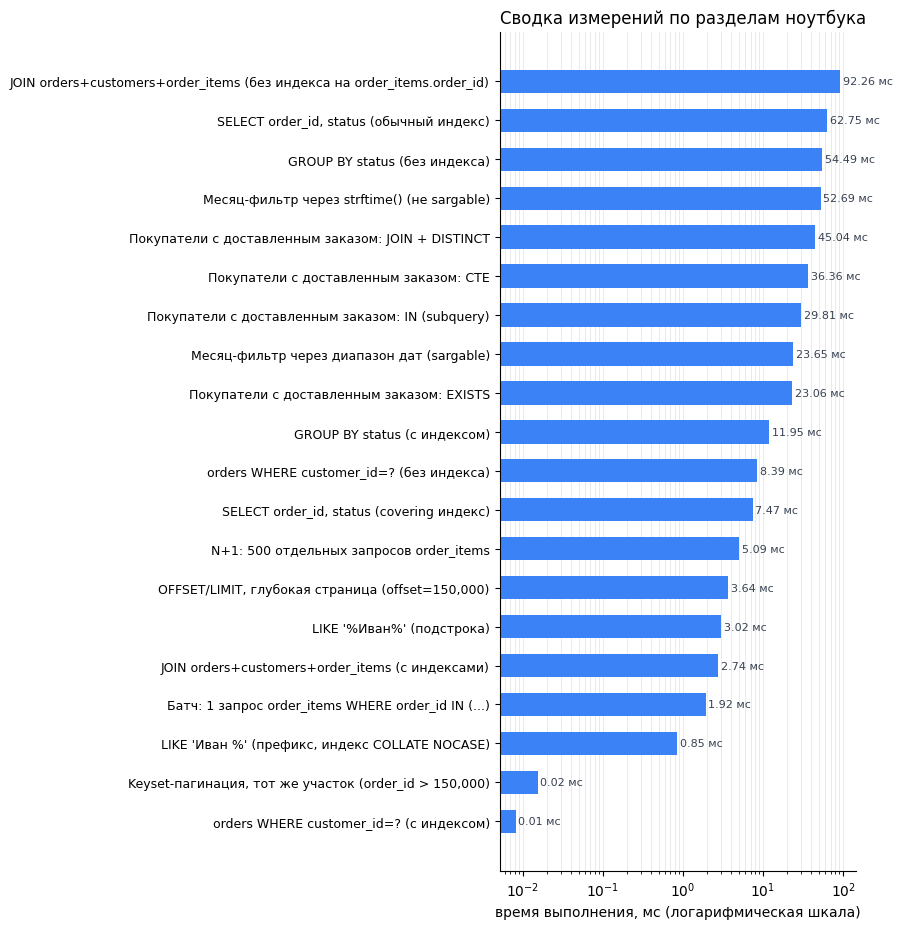

,experiment,time_ms,note
0,orders WHERE customer_id=? (с индексом),0.0082,SEARCH USING INDEX
1,"Keyset-пагинация, тот же участок (order_id > 150,000)",0.0153,
2,"LIKE 'Иван %' (префикс, индекс COLLATE NOCASE)",0.8461,SEARCH USING INDEX
3,Батч: 1 запрос order_items WHERE order_id IN (...),1.9216,1 запрос
4,JOIN orders+customers+order_items (с индексами),2.7353,SEARCH по индексам
5,LIKE '%Иван%' (подстрока),3.0220,"SCAN, индекс не используется"
6,"OFFSET/LIMIT, глубокая страница (offset=150,000)",3.6448,
7,N+1: 500 отдельных запросов order_items,5.0920,500 запросов
8,"SELECT order_id, status (covering индекс)",7.4666,SEARCH USING COVERING INDEX
9,orders WHERE customer_id=? (без индекса),8.3851,SCAN orders


In [19]:
res_df = pd.DataFrame(results)
res_df = res_df.sort_values("time_ms", ascending=True).reset_index(drop=True)

ACCENT = "#3B82F6"  # единый акцентный цвет: все столбцы — одна и та же величина (время)

fig, ax = plt.subplots(figsize=(9, 0.42 * len(res_df) + 1))
y_pos = range(len(res_df))
ax.barh(y_pos, res_df["time_ms"], color=ACCENT, height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(res_df["experiment"], fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("время выполнения, мс (логарифмическая шкала)")
ax.set_title("Сводка измерений по разделам ноутбука", fontsize=12, loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", which="both", color="#e5e7eb", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)

for i, v in enumerate(res_df["time_ms"]):
    ax.text(v * 1.08, i, f"{v:,.2f} мс", va="center", fontsize=8, color="#374151")

plt.tight_layout()
plt.show()

res_df

## 16. Памятка по оптимизации

**Общий чек-лист:**

1. Смотрите план выполнения **до** оптимизации, а не гадайте.
2. Индексируйте столбцы в `WHERE`, `JOIN ON`, `ORDER BY` — но не все подряд
   (индекс замедляет запись и занимает место).
3. Не оборачивайте индексируемый столбец в функцию/приведение типов в `WHERE`.
4. Для составных индексов — порядок столбцов имеет значение (leftmost prefix).
5. Для "узких" горячих запросов рассмотрите покрывающий индекс.
6. На каждый внешний ключ, участвующий в JOIN, обычно нужен индекс.
7. Не делайте N+1 — batch-запросы или JOIN вместо цикла запросов в коде.
8. Для глубокой пагинации — keyset вместо `OFFSET`.
9. Держите статистику планировщика актуальной (`ANALYZE` / `autovacuum`).
10. Измеряйте до и после — интуиция про производительность SQL часто ошибается.

**Перенос концепций на PostgreSQL и MySQL:**

| Концепция                     | SQLite                          | PostgreSQL                                   | MySQL                                    |
|--------------------------------|----------------------------------|-----------------------------------------------|-------------------------------------------|
| Показать план                  | `EXPLAIN QUERY PLAN`             | `EXPLAIN (ANALYZE, BUFFERS)`                  | `EXPLAIN` / `EXPLAIN FORMAT=JSON`         |
| Полный скан таблицы            | `SCAN`                           | `Seq Scan`                                    | `type: ALL`                               |
| Поиск по индексу               | `SEARCH ... USING INDEX`         | `Index Scan` / `Bitmap Index Scan`            | `type: ref` / `range`                     |
| Покрывающий индекс             | `USING COVERING INDEX`           | `Index Only Scan`                             | `Using index` (в столбце Extra)           |
| Обновить статистику            | `ANALYZE`                        | `ANALYZE` (обычно через `autovacuum`)         | `ANALYZE TABLE`                           |
| Индекс на выражение            | `CREATE INDEX ... ON t(lower(x))`| `CREATE INDEX ... ON t(lower(x))`             | `CREATE INDEX ... ON t((LOWER(x)))`       |
| Полнотекстовый поиск           | модуль `FTS5`                    | `tsvector`/`tsquery` + `GIN`, `pg_trgm`       | индекс `FULLTEXT`                         |
| Прочие типы индексов           | только B-tree                    | `GIN`, `GiST`, `BRIN`, `Hash`                 | `BTREE`, `HASH` (для Memory-таблиц)       |
| Материализация CTE             | инлайнится (нет `MATERIALIZED`)  | инлайнится, либо `WITH ... AS MATERIALIZED`   | инлайнится (с MySQL 8)                    |

Логика планировщика (cost-based, на основе статистики) и большинство паттернов
(sargability, покрывающие индексы, leftmost prefix, N+1, keyset-пагинация) —
универсальны для всех реляционных СУБД. Меняется в основном синтаксис и набор
доступных типов индексов.

## 17. Задания для самостоятельной работы

Используйте базу `ecommerce.db`, созданную в этом ноутбуке (переменная `conn`),
и функции `explain()` / `time_query()` из раздела 3.

1. Напишите запрос "топ-10 покупателей по сумме заказов за 2025 год". Посмотрите
   план без индексов, затем создайте индекс(ы) и снова сравните план и время.
2. На `products` создайте составной индекс `(category, price)`. Проверьте, для
   каких из следующих запросов он используется полностью, частично или не
   используется вовсе:
   `WHERE category = ?`, `WHERE price > ?`, `WHERE category = ? AND price > ?`,
   `WHERE price > ? AND category = ?`.
3. Перепишите запрос с `WHERE unit_price * quantity > 1000` (нечестное
   произведение прямо в условии) в sargable-форму. Возможно ли это без
   вычисляемого/сгенерированного столбца?
4. Сравните `NOT IN (SELECT ... )` и `NOT EXISTS` на подзапросе, где возможны
   `NULL`-значения. Добавьте в `orders` строку с `customer_id = NULL` (потребует
   изменить схему) и посмотрите, как по-разному ведут себя `NOT IN` и `NOT EXISTS`.
5. Реализуйте keyset-пагинацию для составного ключа сортировки
   `ORDER BY order_date, order_id` (а не только по одному столбцу) и сравните с
   `OFFSET/LIMIT` на глубокой странице.
6. Найдите в плане запроса с `JOIN` трёх и более таблиц, влияет ли порядок
   таблиц в `FROM`/`JOIN` на итоговый план в SQLite. Подсказка: посмотрите на
   `PRAGMA optimizer_search_limit` и ключевое слово `CROSS JOIN`, которое в
   SQLite отключает перестановку порядка соединения.
7. Создайте `EXPLAIN`-эксперимент, показывающий разницу между индексом с
   `COLLATE NOCASE` и обычным индексом для поиска без учёта регистра
   (`WHERE full_name = 'иван иванов'` вместо `LIKE`).